<a href="https://colab.research.google.com/github/chamarairesh1982/ml-cybersecurity/blob/main/section2_intrusion/section2_intrusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 2 — Network intrusion classification
**Independent learning lab • self-contained Colab notebook**

Identify the provider-labelled category of a completed network flow and assess a separate attack-alert policy. The input is one feature row; the target is one of ten categories (Normal plus nine attacks).

Run in order: problem → source → schema audit → cleaning → duplicate/feature grouping → train/validation split → training EDA → feature engineering → grouped CV → linear/ensemble comparison → numerical neural model → validation selection/alert threshold → final publisher-test evaluation → uncertainty/errors → evidence.

No local dataset, external Python script, credential or other notebook is needed. Public files are fetched only into your Colab runtime. No real-data scores are pre-filled.

## 1. Lecture concepts and scope
| Topic | Application |
|---|---|
| ML foundations | Target, prior baseline, generalisation and limitations |
| Data preparation / EDA | Types, invalid values, missingness, duplicate/conflicting records |
| Feature engineering | Flow ratios, log transforms, training-only imputation/scaling/encoding |
| Supervised learning | Regularised multiclass logistic regression |
| Neural networks / deep learning | Dense MLP, regularisation, dropout, early stopping, class weights |
| Ensemble learning | Random forest and histogram gradient boosting |
| Evaluation | Grouped CV, fixed partitions, macro/per-class metrics, confusion/PR, alert workload |
| Unsupervised learning | Reserved primarily for Section 3 |
| NLP | Not required for structured flow measurements |

The objective is strong **evidence**, not a predetermined winning algorithm. A CNN over arbitrary columns would impose an unsupported neighbourhood structure. Full-flow features are available only after measurement; this notebook does not establish packet-time detection or prevention.

## 2. Runtime and configuration
Classical scikit-learn training uses CPU. The numerical TensorFlow MLP supports CPU, GPU and TPU strategies; actual accelerator compatibility must be checked in your Colab runtime. Colab supplies major packages. The first cell installs only the download/parquet extras. Do not replace a managed TensorFlow installation indiscriminately.

The default uses all cleaned training rows, a bounded three-fold CV search, and two neural seeds. It may take substantial CPU time. Changing settings after examining the final test needs a fresh independent holdout.

In [1]:
%pip -q install "requests>=2.31,<3" "pyarrow>=14"

In [2]:
import os, io, re, json, time, random, hashlib, platform
from pathlib import Path
import importlib.metadata as metadata
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance

SEED = 42
random.seed(SEED); np.random.seed(SEED)
RUN_NEURAL = True
ACCELERATOR = "auto"  # auto, cpu, gpu, tpu
N_JOBS = 2
CV_FOLDS = 3
EPOCHS = 20
BOOTSTRAPS = 200
TARGET_FPR = .01  # Illustrative validation budget on Normal-labelled flows.
RUN_PERMUTATION_IMPORTANCE = False  # Validation-only diagnostic; potentially expensive.
CLASSES = ["Normal","Analysis","Backdoor","DoS","Exploits","Fuzzers",
           "Generic","Reconnaissance","Shellcode","Worms"]
CLASS_TO_ID = {name:i for i,name in enumerate(CLASSES)}
NORMAL_ID = CLASS_TO_ID["Normal"]
CATEGORICAL = ["proto","service","state"]
RAW_NUMERIC = ["dur","spkts","dpkts","sbytes","dbytes","rate","sttl","dttl",
    "sload","dload","sloss","dloss","sinpkt","dinpkt","sjit","djit","swin",
    "stcpb","dwin","dtcpb","tcprtt","synack","ackdat","smean","dmean","trans_depth",
    "response_body_len","ct_srv_src","ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm",
    "ct_dst_sport_ltm","ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd","ct_flw_http_mthd",
    "ct_src_ltm","ct_srv_dst","is_sm_ips_ports"]
# TCP initial sequence numbers can behave as collection-specific identifiers.
NUMERIC = [c for c in RAW_NUMERIC if c not in {"stcpb","dtcpb"}]
PREDICTORS = NUMERIC + CATEGORICAL
DERIVED = ["src_bytes_per_packet","dst_bytes_per_packet",
           "byte_direction_ratio","packet_direction_ratio"]
CORE_NUMERIC = [c for c in NUMERIC if not c.startswith("ct_") and c not in {"sttl","dttl"}]
REVISION = "34ee5744ecb143db1b12623670f754f56c36b94b"
BASE_URL = f"https://huggingface.co/datasets/lacg030175/UNSW-NB15/resolve/{REVISION}"
FILES = {
    "train":("standard/train-00000-of-00001.parquet",
             "0c4a4884abfe24d4545c5ed8cbe1146525cc4ac5c8e0dc8c2b654309a32616ed"),
    "test":("standard/test-00000-of-00001.parquet",
            "70292cae81a8f24aa89ed6c74b01686db36b0750ef9af94da7cdc54e166be598")}
versions = {p:metadata.version(p) for p in ["numpy","pandas","scikit-learn","matplotlib","pyarrow"]}
print("Python:",platform.python_version(),"\nPackages:",versions)
print("Frozen target categories:",CLASSES)

Python: 3.13.15 
Packages: {'numpy': '2.1.3', 'pandas': '2.2.3', 'scikit-learn': '1.6.1', 'matplotlib': '3.10.0', 'pyarrow': '23.0.1'}
Frozen target categories: ['Normal', 'Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']


## 3. Provenance, integrity and benchmark limits
Use the [original UNSW-NB15 description](https://research.unsw.edu.au/projects/unsw-nb15-dataset) and the [pinned mirror card](https://huggingface.co/datasets/lacg030175/UNSW-NB15/blob/34ee5744ecb143db1b12623670f754f56c36b94b/README.md). The original provider describes hybrid normal activity and synthetic attacks, nine attack categories, and published training/test partitions. This mirror's `standard` configuration reformats those partitions into parquet.

Original terms permit academic research and require attribution; commercial use requires agreement. The mirror states a broader CC-BY licence, which this notebook does **not** assume overrides original rights. No data are redistributed here.

The mirror calls this temporal, but the reformatted partition lacks reliable timestamps/session IDs to independently verify chronology. Treat it as the **publisher benchmark split**, not proved future-traffic validation. Do not combine train/test into a favourable random split. Full feature identity and rounded feature groups are only proxies for related flows, not verified session grouping.

The benchmark permits corpus-level learning comparisons. Packet/flow statistics and contextual `ct_*` features may require completed flows/history; availability in a real detector must be established. A declared core-feature ablation excludes TTL/context counts to investigate reliance on collection-specific signals.

In [3]:
def load_partition(name):
    relative_path, expected = FILES[name]
    response = requests.get(f"{BASE_URL}/{relative_path}",timeout=(20,180))
    response.raise_for_status()
    payload = response.content
    digest = hashlib.sha256(payload).hexdigest()
    if digest != expected:
        raise ValueError(f"{name} checksum mismatch; investigate before changing the pin.")
    frame = pd.read_parquet(io.BytesIO(payload))
    return frame, {"sha256":digest,"bytes":len(payload),"rows":len(frame)}

# Test is deliberately not loaded here. It is fetched only after validation decisions freeze.
raw_train, download_train = load_partition("train")
print("Training partition loaded into Colab memory:",download_train)

Training partition loaded into Colab memory: {'sha256': '0c4a4884abfe24d4545c5ed8cbe1146525cc4ac5c8e0dc8c2b654309a32616ed', 'bytes': 12773520, 'rows': 175341}


## 4. Raw training audit and deterministic cleaning
Inspect types, missingness, categorical cardinality and target counts. Never use `id`, `label`, `attack_cat` or partition identity as predictors. Validate consistency between category and binary labels. Numeric invalid/infinite/negative values become missing and are counted; do not delete high traffic values merely as statistical outliers.

Normalise category spelling (including Backdoors → Backdoor). Empty categorical fields become missing; the service `-` marker is retained as a meaningful 'no named service' category. Missing labels and contradictory feature-identical targets are excluded with counts.

Hash only the actual base predictor representation. Retain one consistent copy of feature-identical rows. Scores on deduplicated, overlap-filtered test rows will differ from an unmodified row-weighted published benchmark, so explicitly report the evaluation population.

In [4]:
def clean_partition(frame):
    expected = set(RAW_NUMERIC + CATEGORICAL + ["attack_cat","label"])
    if not expected.issubset(frame.columns):
        raise ValueError(f"Missing fields: {sorted(expected - set(frame.columns))}")
    unexpected = set(frame.columns)-expected-{"id","__index_level_0__"}
    if unexpected:
        raise ValueError(f"Unexpected columns need explicit review: {sorted(unexpected)}")
    audit = {"input_rows":len(frame)}
    work = frame.copy()
    category = work["attack_cat"].astype("string").str.strip().replace({"Backdoors":"Backdoor"})
    missing_label = category.isna() | category.eq("") | work["label"].isna()
    audit["missing_target_rows_removed"] = int(missing_label.sum())
    work = work.loc[~missing_label].copy()
    category = category.loc[~missing_label]
    unknown = set(category.unique())-set(CLASSES)
    if unknown:
        raise ValueError(f"Unexpected target categories: {unknown}")
    binary = pd.to_numeric(work["label"],errors="coerce")
    if not binary.isin([0,1]).all():
        raise ValueError("Binary targets must be 0 or 1.")
    if not ((category != "Normal").astype(int).to_numpy() == binary.to_numpy()).all():
        raise ValueError("Category/binary-label inconsistency; investigate labels.")
    work["target"] = category.map(CLASS_TO_ID).astype("int32")
    invalid_counts = {}
    for column in RAW_NUMERIC:
        original = work[column]
        values = pd.to_numeric(original,errors="coerce").astype("float64")
        invalid = ~np.isfinite(values) | (values < 0)
        invalid_counts[column] = int((invalid & original.notna()).sum())
        work[column] = values.mask(invalid,np.nan)
    for column in CATEGORICAL:
        values = work[column].astype("string").str.strip().str.lower()
        work[column] = values.mask(values.eq(""),pd.NA).astype(object)
        work[column] = work[column].where(pd.notna(work[column]),np.nan)
    # index=False excludes row identity; a 64-bit feature hash is a practical duplicate proxy.
    work["feature_hash"] = pd.util.hash_pandas_object(work[PREDICTORS],index=False).astype("uint64")
    clashes = work.groupby("feature_hash")["target"].nunique()
    conflicted = work["feature_hash"].isin(clashes[clashes>1].index)
    audit["conflicting_feature_duplicate_rows_removed"] = int(conflicted.sum())
    work = work.loc[~conflicted].copy()
    audit["consistent_feature_duplicate_rows_removed"] = int(work["feature_hash"].duplicated().sum())
    work = work.drop_duplicates("feature_hash").reset_index(drop=True)
    audit["retained_rows"] = len(work)
    audit["invalid_numeric_values_to_missing"] = invalid_counts
    return work[PREDICTORS+["target","feature_hash"]], audit

display(pd.DataFrame({"dtype":raw_train.dtypes.astype(str),"missing":raw_train.isna().sum()}))
display(raw_train["attack_cat"].value_counts(dropna=False).to_frame("training_target_count"))
print("Raw training shape:",raw_train.shape)
train_pool, cleaning_train = clean_partition(raw_train)
del raw_train
display(pd.Series({k:v for k,v in cleaning_train.items() if isinstance(v,int)}).to_frame("count"))
display(pd.Series(cleaning_train["invalid_numeric_values_to_missing"]).to_frame("invalid_values"))

,dtype,missing
ackdat,float64,0
attack_cat,object,0
ct_dst_ltm,int64,0
ct_dst_sport_ltm,int64,0
ct_dst_src_ltm,int64,0
ct_flw_http_mthd,int64,0
ct_ftp_cmd,int64,0
ct_src_dport_ltm,int64,0
ct_src_ltm,int64,0
ct_srv_dst,int64,0


,training_target_count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133


Raw training shape: (175341, 44)


,count
input_rows,175341
missing_target_rows_removed,0
conflicting_feature_duplicate_rows_removed,30528
consistent_feature_duplicate_rows_removed,45545
retained_rows,99268


,invalid_values
dur,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0
sttl,0
dttl,0
sload,0
dload,0


## 5. Related-feature grouping and fixed validation split
Round finite **core-feature** numeric values to four significant digits for an approximate related-flow fingerprint; keep categorical values and missingness. Using core features ensures identical inputs to the core ablation cannot cross partitions even when excluded TTL/context features differ. This deterministic, label-free proxy can group near-identical measurements but cannot recover sessions or campaigns. Hash collisions are possible, though improbable at this size.

Reserve one fixed fold of a five-fold stratified **group** split for validation. Use the remaining folds for training. Do not choose folds by their score. Check each class has independent groups and each CV fold contains the complete taxonomy; stop rather than silently remove a rare class.

In [5]:
def rounded_feature_groups(frame):
    rounded = frame[CORE_NUMERIC + CATEGORICAL].copy()
    for column in CORE_NUMERIC:
        values = rounded[column].to_numpy(dtype="float64")
        nonzero = np.isfinite(values) & (values != 0)
        precision = np.ones_like(values)
        precision[nonzero] = np.power(10.0,np.clip(3-np.floor(np.log10(np.abs(values[nonzero]))),-300,300))
        rounded[column] = np.round(values*precision)/precision
    return pd.util.hash_pandas_object(rounded,index=False).to_numpy(dtype="uint64")

train_pool["group"] = rounded_feature_groups(train_pool)
group_counts = train_pool.groupby("target")["group"].nunique()
display(group_counts.rename(index=dict(enumerate(CLASSES))).to_frame("independent_feature_groups"))
if set(group_counts.index) != set(range(len(CLASSES))) or group_counts.min() < 10:
    raise ValueError("Every target needs at least ten independent feature groups for this design.")
splitter = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED)
train_indices,val_indices = next(splitter.split(train_pool,train_pool["target"],train_pool["group"]))
training = train_pool.iloc[train_indices].reset_index(drop=True)
validation = train_pool.iloc[val_indices].reset_index(drop=True)
assert not set(training["group"]) & set(validation["group"])
X_train,y_train = training[PREDICTORS],training["target"].to_numpy()
X_val,y_val = validation[PREDICTORS],validation["target"].to_numpy()
g_train = training["group"].to_numpy()
if set(y_train)!=set(range(len(CLASSES))) or set(y_val)!=set(range(len(CLASSES))):
    raise ValueError("Train/validation is missing a category; inspect grouping rather than search lucky splits.")
cv = StratifiedGroupKFold(n_splits=CV_FOLDS,shuffle=True,random_state=SEED+1)
cv_splits = list(cv.split(X_train,y_train,g_train))
for tr,va in cv_splits:
    assert not set(g_train[tr]) & set(g_train[va])
    if set(y_train[tr])!=set(range(len(CLASSES))) or set(y_train[va])!=set(range(len(CLASSES))):
        raise ValueError("A CV fold lacks a target category.")
print("Training rows:",len(training),"validation rows:",len(validation))
print("Test partition remains unfetched.")

,independent_feature_groups
target,
Normal,47312
Analysis,376
Backdoor,400
DoS,2456
Exploits,18329
Fuzzers,12610
Generic,594
Reconnaissance,5081
Shellcode,951


Training rows: 80091 validation rows: 19177
Test partition remains unfetched.


## 6. Training-only EDA and availability review
Plot class support, missingness and duration. Inspect skew rather than deleting rare attacks or large values. Class weights are tuned inside training; no resampling before splitting. Do not convert rare attacks into Normal.

Some learned predictors may be dataset shortcuts: inspect TTL and contextual counts, use the core-feature comparison, and acknowledge missing independent deployment data.

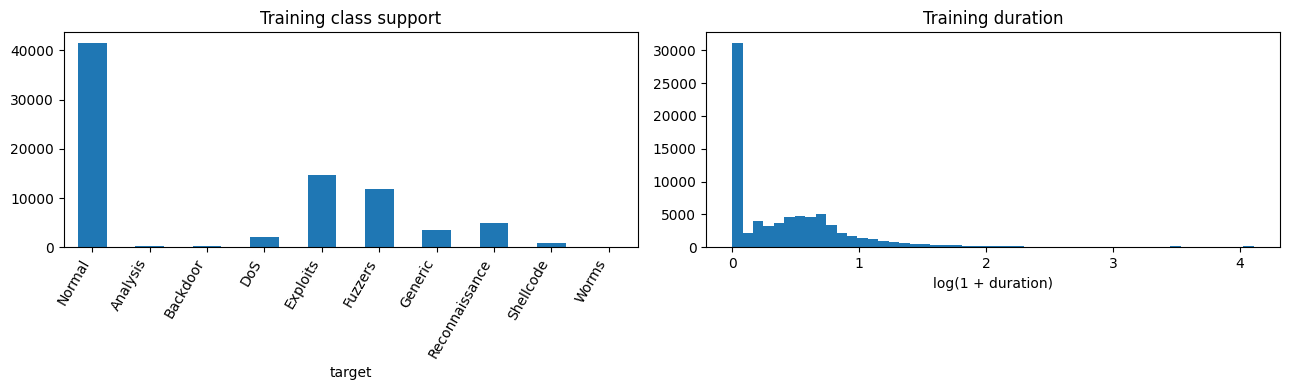

,missing_fraction
dur,0.0
spkts,0.0
dpkts,0.0
sbytes,0.0
dbytes,0.0
rate,0.0
sttl,0.0
dttl,0.0
sload,0.0
dload,0.0


,training_cardinality
proto,81
service,13
state,8


Normal fraction: 0.5192343709030978


In [6]:
fig,axes = plt.subplots(1,2,figsize=(13,4))
training["target"].value_counts().reindex(range(len(CLASSES)),fill_value=0).plot.bar(ax=axes[0])
axes[0].set_xticklabels(CLASSES,rotation=60,ha="right"); axes[0].set_title("Training class support")
axes[1].hist(np.log1p(training["dur"].dropna()),bins=50)
axes[1].set_xlabel("log(1 + duration)"); axes[1].set_title("Training duration")
plt.tight_layout(); plt.show()
display(X_train.isna().mean().sort_values(ascending=False).head(10).to_frame("missing_fraction"))
display(X_train[CATEGORICAL].nunique().to_frame("training_cardinality"))
print("Normal fraction:",float(np.mean(y_train==NORMAL_ID)))

## 7. Feature engineering and leakage-safe pipelines
Create directional ratios and bytes per packet using only row-local measurements; zero denominators produce missing values, then a fitted imputer handles them. Preserve all missing indicators.

Numeric pipeline: median imputation → nonnegative log1p → standardisation for linear/neural models. Tree models use imputation/log transforms without scaling. One-hot encode protocol/service/state, treating unknown categories safely. Rare-category grouping is learned only from each fit. Dense float32 matrices are bounded by feature counts; never fit the encoder or imputer outside training.

The core-feature boosted model excludes TTL and contextual count features. This is a predeclared availability/artifact ablation, not a claim that the remaining features are causally valid.

In [7]:
class FlowRatios(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None):
        return self
    def transform(self,X):
        frame=X.copy()
        def divide(numerator,denominator):
            a=frame[numerator].to_numpy(dtype="float64")
            b=frame[denominator].to_numpy(dtype="float64")
            out=np.full(len(frame),np.nan)
            with np.errstate(over="ignore",invalid="ignore"):
                np.divide(a,b,out=out,where=np.isfinite(b)&(b>0))
            out[~np.isfinite(out)] = np.nan
            return out
        frame["src_bytes_per_packet"]=divide("sbytes","spkts")
        frame["dst_bytes_per_packet"]=divide("dbytes","dpkts")
        frame["byte_direction_ratio"]=divide("sbytes","dbytes")
        frame["packet_direction_ratio"]=divide("spkts","dpkts")
        return frame

def log_numeric(values):
    return np.log1p(values).astype("float32")

def preprocessing(scale=False,core=False):
    numeric_columns=(CORE_NUMERIC if core else NUMERIC)+DERIVED
    steps=[("impute",SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True)),
           ("log",FunctionTransformer(log_numeric,feature_names_out="one-to-one"))]
    if scale:
        steps.append(("scale",StandardScaler()))
    categorical=Pipeline([
        ("impute",SimpleImputer(strategy="constant",fill_value="missing")),
        ("encode",OneHotEncoder(handle_unknown="infrequent_if_exist",
            min_frequency=10,sparse_output=False,dtype=np.float32))])
    transform=ColumnTransformer([
        ("numeric",Pipeline(steps),numeric_columns),
        ("categorical",categorical,CATEGORICAL)],sparse_threshold=0)
    return Pipeline([("ratios",FlowRatios()),("columns",transform)])

def candidate(model,scale=False,core=False):
    return Pipeline([("prepare",preprocessing(scale,core)),("model",model)])

experiments={
    "logistic":(candidate(LogisticRegression(max_iter=1500,random_state=SEED),scale=True),
        {"model__C":[.3,1.0,3.0],"model__class_weight":[None,"balanced"]}),
    "forest":(candidate(RandomForestClassifier(n_estimators=150,min_samples_leaf=2,
                    n_jobs=1,random_state=SEED)),
        {"model__max_depth":[12,None],"model__class_weight":[None,"balanced"]}),
    "boosting":(candidate(HistGradientBoostingClassifier(max_iter=100,
                  learning_rate=.08,early_stopping=False,random_state=SEED)),
        {"model__max_leaf_nodes":[15,31],"model__class_weight":[None,"balanced"]}),
    "boosting_core":(candidate(HistGradientBoostingClassifier(max_iter=100,
                   learning_rate=.08,early_stopping=False,class_weight="balanced",
                   random_state=SEED),core=True),
        {"model__max_leaf_nodes":[15,31]})
}
print("Declared candidates:",list(experiments))
print("Histogram boosting internal early stopping is disabled; grouped outer CV selects settings.")

Declared candidates: ['logistic', 'forest', 'boosting', 'boosting_core']
Histogram boosting internal early stopping is disabled; grouped outer CV selects settings.


## 8. Grouped CV and classical/ensemble comparison
Tune on the same training-only folds using **macro-F1**, treating rare categories equally rather than letting frequent categories dominate accuracy. Report train/CV gaps and CV variation. These CV scores are for development; final generalisation is assessed on the fixed publisher-test partition.

No full-data scaling/encoding, outcome-driven feature selection, or synthetic resampling occurs before CV. The prior baseline is fitted without feature dependence.

In [8]:
models,validation_probabilities,fit_seconds,cv_records={},{},{},[]
baseline=DummyClassifier(strategy="prior").fit(np.zeros((len(y_train),1)),y_train)
models["prior"]=baseline
validation_probabilities["prior"]=baseline.predict_proba(np.zeros((len(y_val),1)))
fit_seconds["prior"]=0.0
for name,(pipeline,grid) in experiments.items():
    print("Fitting grouped search:",name)
    start=time.perf_counter()
    search=GridSearchCV(pipeline,grid,scoring="f1_macro",cv=cv_splits,
        n_jobs=N_JOBS,refit=True,return_train_score=True,error_score="raise")
    search.fit(X_train,y_train)
    fit_seconds[name]=time.perf_counter()-start
    models[name]=search.best_estimator_
    assert np.array_equal(models[name].classes_,np.arange(len(CLASSES)))
    validation_probabilities[name]=models[name].predict_proba(X_val)
    best=search.best_index_
    cv_records.append({"model":name,"CV_macro_F1":search.best_score_,
        "CV_std":search.cv_results_["std_test_score"][best],
        "train_macro_F1":search.cv_results_["mean_train_score"][best],
        "search_seconds":fit_seconds[name],"parameters":search.best_params_})
cv_table=pd.DataFrame(cv_records).sort_values("CV_macro_F1",ascending=False)
display(cv_table)

Fitting grouped search: logistic
Fitting grouped search: forest
Fitting grouped search: boosting
Fitting grouped search: boosting_core


,model,CV_macro_F1,CV_std,train_macro_F1,search_seconds,parameters
2,boosting,0.731306,0.005792,0.882969,382.833755,"{'model__class_weight': 'balanced', 'model__ma..."
1,forest,0.730483,0.006935,0.955500,218.588976,"{'model__class_weight': 'balanced', 'model__ma..."
3,boosting_core,0.663093,0.009854,0.812485,182.568890,{'model__max_leaf_nodes': 31}
0,logistic,0.549992,0.013358,0.565762,318.557763,"{'model__C': 3.0, 'model__class_weight': None}"


## 9. Numerical deep-learning comparator
Fit an independent training-only imputer/encoder/scaler for the MLP. Use dense layers, L2 regularisation, dropout, weighted training and validation early stopping. The target is ten-category softmax; scores are not assumed calibrated.

Train two fixed seeds. Learned categorical encodings become numeric arrays before GPU/TPU execution. Static full training batches repeat at most one partial batch instead of dropping rare-class examples. Validation/prediction use a fixed feature width. Loss chooses stopping epochs; validation macro-F1 selects among frozen candidates.

Strategy: MirroredStrategy replicas: 1
Numeric input width: 71 training MB: 22.745844
Epoch 1/20
1252/1252 - 12s - 9ms/step - accuracy: 0.6412 - loss: 1.2678 - val_accuracy: 0.6901 - val_loss: 0.8633
Epoch 2/20
1252/1252 - 9s - 7ms/step - accuracy: 0.7041 - loss: 0.9719 - val_accuracy: 0.7115 - val_loss: 0.8356
Epoch 3/20
1252/1252 - 9s - 7ms/step - accuracy: 0.7191 - loss: 0.8965 - val_accuracy: 0.7164 - val_loss: 0.7624
Epoch 4/20
1252/1252 - 8s - 7ms/step - accuracy: 0.7302 - loss: 0.8328 - val_accuracy: 0.7356 - val_loss: 0.7446
Epoch 5/20
1252/1252 - 9s - 7ms/step - accuracy: 0.7341 - loss: 0.8167 - val_accuracy: 0.7459 - val_loss: 0.7278
Epoch 6/20
1252/1252 - 9s - 7ms/step - accuracy: 0.7385 - loss: 0.7725 - val_accuracy: 0.7349 - val_loss: 0.7077
Epoch 7/20
1252/1252 - 8s - 6ms/step - accuracy: 0.7395 - loss: 0.7769 - val_accuracy: 0.7372 - val_loss: 0.7040
Epoch 8/20
1252/1252 - 9s - 7ms/step - accuracy: 0.7420 - loss: 0.7537 - val_accuracy: 0.7482 - val_loss: 0.6816
Epoch 9/2

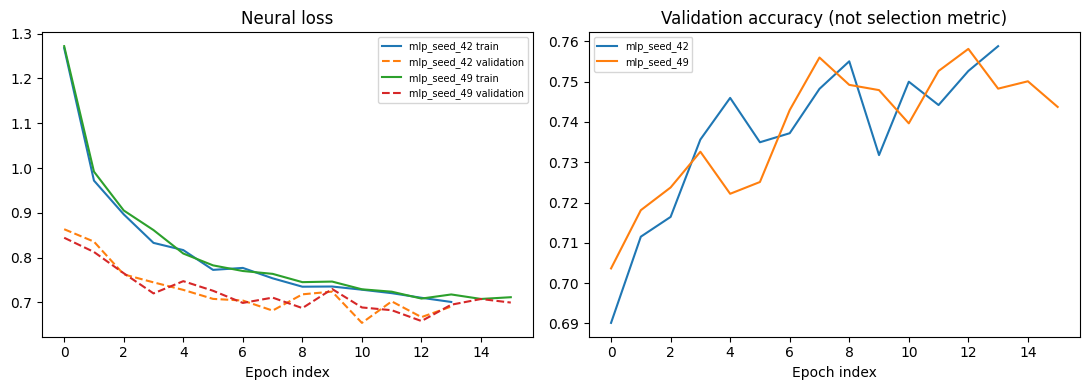

In [9]:
if RUN_NEURAL:
    import tensorflow as tf
    versions["tensorflow"]=tf.__version__
    if ACCELERATOR not in {"auto","cpu","gpu","tpu"}:
        raise ValueError("Unknown ACCELERATOR.")
    strategy=None
    if ACCELERATOR in {"auto","tpu"}:
        try:
            resolver=tf.distribute.cluster_resolver.TPUClusterResolver()
        except ValueError:
            if ACCELERATOR=="tpu":
                raise RuntimeError("TPU requested but unavailable. Select a TPU Colab runtime.")
        else:
            tf.config.experimental_connect_to_cluster(resolver)
            tf.tpu.experimental.initialize_tpu_system(resolver)
            strategy=tf.distribute.TPUStrategy(resolver)
    if strategy is None:
        devices=tf.config.list_logical_devices("GPU")
        if ACCELERATOR=="gpu" and not devices:
            raise RuntimeError("GPU requested but unavailable.")
        strategy=(tf.distribute.MirroredStrategy() if devices and ACCELERATOR!="cpu"
                  else tf.distribute.OneDeviceStrategy("/CPU:0"))
    print("Strategy:",type(strategy).__name__,"replicas:",strategy.num_replicas_in_sync)
    neural_preprocessor=preprocessing(scale=True)
    train_matrix=neural_preprocessor.fit_transform(X_train,y_train).astype("float32")
    val_matrix=neural_preprocessor.transform(X_val).astype("float32")
    if not np.isfinite(train_matrix).all() or not np.isfinite(val_matrix).all():
        raise ValueError("Neural matrix contains nonfinite values.")
    print("Numeric input width:",train_matrix.shape[1],
          "training MB:",train_matrix.nbytes/1e6)
    GLOBAL_BATCH=64*strategy.num_replicas_in_sync
    def neural_dataset(matrix,labels=None,training=False):
        ds=(tf.data.Dataset.from_tensor_slices(matrix) if labels is None
            else tf.data.Dataset.from_tensor_slices((matrix,labels.astype("int32"))))
        if training:
            ds=ds.shuffle(len(matrix),seed=SEED,reshuffle_each_iteration=True)
            ds=ds.repeat().take(int(np.ceil(len(matrix)/GLOBAL_BATCH))*GLOBAL_BATCH)
        return ds.batch(GLOBAL_BATCH,drop_remainder=training).prefetch(tf.data.AUTOTUNE)

    class_counts=np.bincount(y_train,minlength=len(CLASSES))
    weights={i:len(y_train)/(len(CLASSES)*int(count)) for i,count in enumerate(class_counts)}
    neural_histories={}
    for seed in [SEED,SEED+7]:
        tf.keras.utils.set_random_seed(seed)
        with strategy.scope():
            network=tf.keras.Sequential([
                tf.keras.Input(shape=(train_matrix.shape[1],),dtype="float32"),
                tf.keras.layers.Dense(128,activation="relu",
                    kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
                tf.keras.layers.Dropout(.3),
                tf.keras.layers.Dense(64,activation="relu",
                    kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
                tf.keras.layers.Dropout(.2),
                tf.keras.layers.Dense(len(CLASSES),activation="softmax")])
            network.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="sparse_categorical_crossentropy",metrics=["accuracy"])
        start=time.perf_counter()
        history=network.fit(neural_dataset(train_matrix,y_train,True),
            validation_data=neural_dataset(val_matrix,y_val),epochs=EPOCHS,
            class_weight=weights,shuffle=False,verbose=2,
            callbacks=[tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",patience=3,restore_best_weights=True)])
        name=f"mlp_seed_{seed}"
        models[name]=network
        fit_seconds[name]=time.perf_counter()-start
        validation_probabilities[name]=network.predict(neural_dataset(val_matrix),verbose=0)
        neural_histories[name]=history.history
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    for name,h in neural_histories.items():
        axes[0].plot(h["loss"],label=name+" train")
        axes[0].plot(h["val_loss"],"--",label=name+" validation")
        axes[1].plot(h["val_accuracy"],label=name)
    axes[0].set_title("Neural loss");axes[1].set_title("Validation accuracy (not selection metric)")
    for ax in axes:ax.set_xlabel("Epoch index");ax.legend(fontsize=7)
    plt.tight_layout();plt.show()
else:
    print("Neural comparator disabled; classical experiment remains available.")

## 10. Freeze category selection and attack-alert thresholds
Select the multiclass candidate on validation macro-F1, then lower Normal misclassification rate, then lower fitting cost. This is the declared category-classification objective.

Separately choose each candidate's **attack score** threshold (`1 − P(Normal)`) to maximise validation attack recall under the 1% Normal false-alert budget. Softmax/prior probabilities are model scores, not guaranteed calibrated risks. Do not confuse this alert policy with category argmax predictions. Never refit on validation after threshold selection.

In [10]:
def alert_threshold(binary_targets,scores,max_fpr):
    order=np.argsort(-scores,kind="stable")
    ordered_scores,ordered_y=np.asarray(scores)[order],np.asarray(binary_targets)[order]
    edges=np.r_[np.flatnonzero(np.diff(ordered_scores)),len(scores)-1]
    tp=np.cumsum(ordered_y)[edges]
    fp=edges+1-tp
    recall=tp/max(1,int(np.sum(binary_targets==1)))
    fpr=fp/max(1,int(np.sum(binary_targets==0)))
    feasible=np.flatnonzero(fpr<=max_fpr)
    if not len(feasible):
        return float(np.nextafter(np.max(scores),np.inf))
    best=max(feasible,key=lambda i:(recall[i],-fpr[i],ordered_scores[edges[i]]))
    return float(ordered_scores[edges[best]])

thresholds,selection_rows={},[]
binary_val=(y_val!=NORMAL_ID).astype(int)
for name,probabilities in validation_probabilities.items():
    if probabilities.shape!=(len(y_val),len(CLASSES)) or not np.isfinite(probabilities).all():
        raise ValueError(f"Invalid probability matrix for {name}")
    predicted=probabilities.argmax(axis=1)
    attack_scores=1-probabilities[:,NORMAL_ID]
    thresholds[name]=alert_threshold(binary_val,attack_scores,TARGET_FPR)
    alerts=attack_scores>=thresholds[name]
    normal=y_val==NORMAL_ID
    selection_rows.append({"model":name,
        "validation_macro_F1":f1_score(y_val,predicted,labels=np.arange(len(CLASSES)),average="macro",zero_division=0),
        "normal_category_FPR":float(np.mean(predicted[normal]!=NORMAL_ID)),
        "alert_recall":recall_score(binary_val,alerts,zero_division=0),
        "alert_FPR":float(np.mean(alerts[normal])),
        "fit_seconds":fit_seconds[name],"alert_threshold":thresholds[name]})
selection_table=pd.DataFrame(selection_rows).sort_values(
    ["validation_macro_F1","normal_category_FPR","fit_seconds"],ascending=[False,True,True])
display(selection_table)
winner=selection_table.iloc[0]["model"]
print("Frozen multiclass winner:",winner)
experiment_config={"seed":SEED,"taxonomy":CLASSES,"winner":winner,"target_alert_FPR":TARGET_FPR,
    "revision":REVISION,"cv_folds":CV_FOLDS,"group_significant_digits":4,
    "grouping_features":"core numeric measurements plus protocol/service/state",
    "run_neural":RUN_NEURAL,"neural_seeds":[SEED,SEED+7] if RUN_NEURAL else [],
    "max_epochs":EPOCHS,"strategy":type(strategy).__name__ if RUN_NEURAL else "classical CPU"}

,model,validation_macro_F1,normal_category_FPR,alert_recall,alert_FPR,fit_seconds,alert_threshold
2,forest,0.748261,0.106799,0.744452,0.009926,218.588976,0.923938
3,boosting,0.720732,0.165558,0.721929,0.009926,382.833755,0.977570
4,boosting_core,0.662560,0.187593,0.633817,0.009926,182.568890,0.986955
1,logistic,0.558301,0.116526,0.591848,0.009926,318.557763,0.927278
6,mlp_seed_49,0.545155,0.200794,0.608657,0.009926,139.088943,0.993529
5,mlp_seed_42,0.524971,0.200596,0.594595,0.009926,125.593277,0.988219
0,prior,0.068884,0.000000,0.000000,0.000000,0.000000,0.480766


Frozen multiclass winner: forest


## 11. Optional validation feature sensitivity
Permutation importance describes predictive dependence, not causality. Compute it on validation only for the best CV classical candidate. It is optional because shuffling a flow feature can create unrealistic combinations. The core-feature comparison is already predeclared. Do not redesign features after looking at final-test errors and still call that test untouched.

In [11]:
if RUN_PERMUTATION_IMPORTANCE:
    classical=cv_table.iloc[0]["model"]
    influence=permutation_importance(models[classical],X_val,y_val,
        scoring="f1_macro",n_repeats=3,random_state=SEED,n_jobs=N_JOBS)
    table=pd.DataFrame({"feature":PREDICTORS,"mean_drop":influence.importances_mean,
                        "std":influence.importances_std}).sort_values("mean_drop",ascending=False)
    display(table.head(12))
else:
    print("Validation permutation importance disabled.")

Validation permutation importance disabled.


## 12. Final held-out test: fetch only now
A session guard claims the final test before reading it and blocks reruns. Restarting bypasses a code guard, so discipline still matters. Test cleaning uses the same declared rules, independent of model scores.

Report exact overlap and rounded-group overlap with **both training and validation**. Evaluate on novel groups after excluding these overlaps; this is a cleaned novelty subset of the published test, not the original benchmark population. Report retained counts/class support and exclusions. No claim of session or chronological independence is made.

Do not alter model settings or thresholds after this cell. A different candidate's higher test score does not replace the validation winner.

In [12]:
if globals().get("_section2_test_evaluated",False):
    raise RuntimeError("Section 2 test already evaluated. Further development needs a fresh holdout.")
_section2_test_evaluated=True
raw_test,download_test=load_partition("test")
test_pool,cleaning_test=clean_partition(raw_test)
del raw_test
test_pool["group"]=rounded_feature_groups(test_pool)
exact_overlap=test_pool["feature_hash"].isin(train_pool["feature_hash"])
group_overlap=test_pool["group"].isin(train_pool["group"])
overlap_audit={"exact_overlap_rows":int(exact_overlap.sum()),
    "rounded_group_overlap_rows":int(group_overlap.sum()),
    "total_overlap_rows_removed":int((exact_overlap|group_overlap).sum())}
testing=test_pool.loc[~(exact_overlap|group_overlap)].reset_index(drop=True)
print("Test cleaning:",{k:v for k,v in cleaning_test.items() if isinstance(v,int)})
print("Overlap filtering:",overlap_audit,"retained test rows:",len(testing))
if len(testing)==0 or not (testing["target"]==NORMAL_ID).any() or not (testing["target"]!=NORMAL_ID).any():
    raise ValueError("Novelty test needs both Normal and attack-labelled rows.")
assert not set(testing["group"]) & set(train_pool["group"])
X_test,y_test=testing[PREDICTORS],testing["target"].to_numpy()
binary_test=(y_test!=NORMAL_ID).astype(int)
g_test=testing["group"].to_numpy()
support=np.bincount(y_test,minlength=len(CLASSES))
display(pd.DataFrame({"category":CLASSES,"retained_test_support":support}))
if np.any(support==0):
    print("Some categories are absent after filtering. Macro-F1 uses the fixed taxonomy; AP/ROC omit undefined class curves.")
if RUN_NEURAL:
    test_matrix=neural_preprocessor.transform(X_test).astype("float32")
unseen_rates={column:float((~X_test[column].isin(set(X_train[column].dropna()))).mean())
              for column in CATEGORICAL}
print("Test unseen-or-missing categorical fractions:",unseen_rates)

Test cleaning: {'input_rows': 82332, 'missing_target_rows_removed': 0, 'conflicting_feature_duplicate_rows_removed': 8809, 'consistent_feature_duplicate_rows_removed': 20152, 'retained_rows': 53371}
Overlap filtering: {'exact_overlap_rows': 954, 'rounded_group_overlap_rows': 7747, 'total_overlap_rows_removed': 7747} retained test rows: 45624


,category,retained_test_support
0,Normal,30710
1,Analysis,58
2,Backdoor,57
3,DoS,1140
4,Exploits,7000
5,Fuzzers,3823
6,Generic,656
7,Reconnaissance,1856
8,Shellcode,284
9,Worms,40


Test unseen-or-missing categorical fractions: {'proto': 8.76731544800982e-05, 'service': 0.0, 'state': 0.00010959144310012274}


## 13. Final category and alert metrics
Primary category metrics: fixed-taxonomy macro-F1, macro recall, per-class precision/recall/F1/support, accuracy and normalised confusion matrix. One-vs-rest AP and ROC-AUC are computed only for categories with both positive and negative test examples; report how many curves are defined.

Alert metrics use the validation-selected binary thresholds: precision, recall, FPR and false alerts per 1,000 Normal-labelled flows. Alert workload depends on deployment prevalence and volume. No automatic recalibration occurs when test FPR exceeds the budget.

,model,selected_on_validation,accuracy,macro_F1,macro_recall,weighted_F1,macro_OVR_AP,macro_OVR_ROC_AUC,defined_OVR_classes,alert_AP,alert_precision,alert_recall,alert_FPR,alerts_per_1000_Normal,alert_TN,alert_FP,alert_FN,alert_TP,fit_seconds,test_seconds
0,prior,False,0.673111,0.080462,0.100000,0.541599,0.100000,0.500000,10,0.326889,0.000000,0.000000,0.000000,0.000000,30710,0,14914,0,0.000000,0.003081
1,logistic,False,0.722690,0.347201,0.377522,0.740084,0.379008,0.934667,10,0.885009,0.916088,0.584149,0.025985,25.985021,29912,798,6202,8712,318.557763,0.254112
2,forest,True,0.749803,0.550922,0.603899,0.783632,0.618830,0.949255,10,0.941599,0.931405,0.749296,0.026799,26.799088,29887,823,3739,11175,218.588976,1.492574
3,boosting,False,0.671423,0.519542,0.639260,0.726775,0.579185,0.965557,10,0.920361,0.888654,0.732064,0.044546,44.545751,29342,1368,3996,10918,382.833755,5.474978
4,boosting_core,False,0.659456,0.480809,0.625411,0.719173,0.542189,0.963038,10,0.905733,0.941767,0.603996,0.018137,18.137415,30153,557,5906,9008,182.568890,5.236710
5,mlp_seed_42,False,0.619016,0.341882,0.568957,0.687355,0.427319,0.932412,10,0.880672,0.884830,0.605807,0.038294,38.293715,29534,1176,5879,9035,125.593277,4.408731
6,mlp_seed_49,False,0.612200,0.330631,0.564859,0.678080,0.415243,0.937950,10,0.882516,0.888707,0.618949,0.037642,37.642462,29554,1156,5683,9231,139.088943,3.794864


,precision,recall,f1-score,support
Normal,0.983144,0.733116,0.839918,30710.000000
Analysis,0.000000,0.000000,0.000000,58.000000
Backdoor,0.566667,0.596491,0.581197,57.000000
DoS,0.643939,0.372807,0.472222,1140.000000
Exploits,0.753670,0.902143,0.821250,7000.000000
Fuzzers,0.298564,0.756212,0.428106,3823.000000
Generic,0.881579,0.306402,0.454751,656.000000
Reconnaissance,0.853963,0.847522,0.850730,1856.000000
Shellcode,0.212746,0.799296,0.336047,284.000000
Worms,0.725000,0.725000,0.725000,40.000000


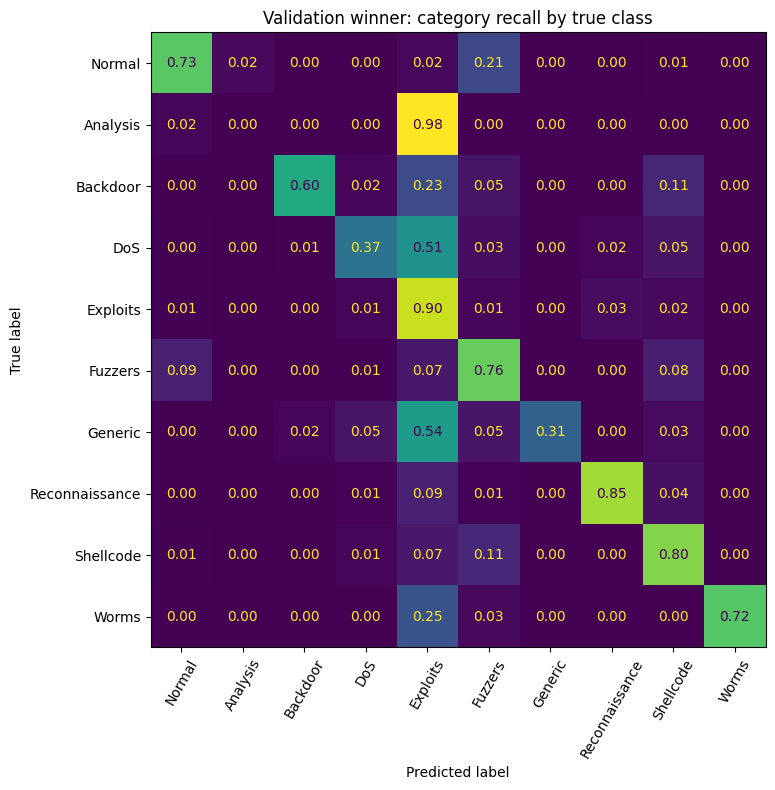

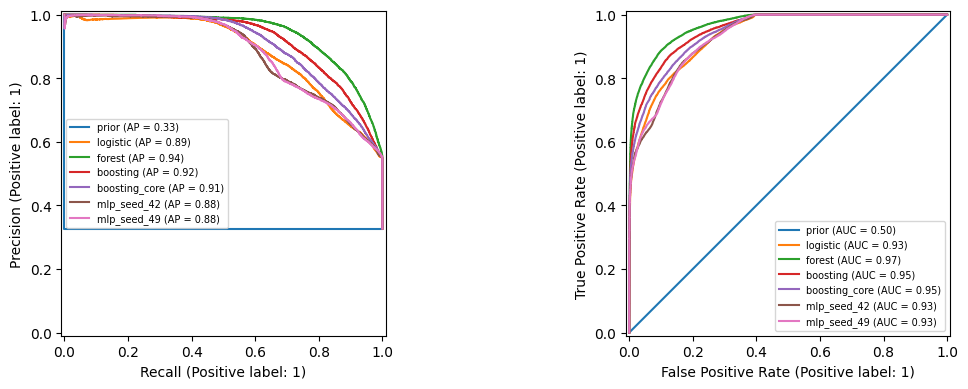

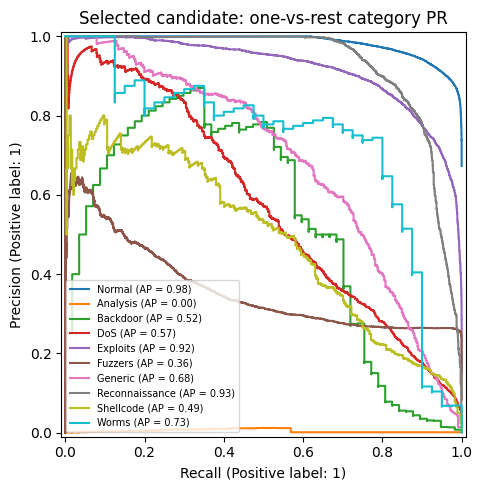

Winner's test FPR exceeds the validation budget. Report this shift; do not retune on test.


In [13]:
def category_metrics(y,probabilities):
    predicted=probabilities.argmax(axis=1)
    ap,roc=[],[]
    for i in range(len(CLASSES)):
        indicator=(y==i).astype(int)
        if indicator.min()!=indicator.max():
            ap.append(average_precision_score(indicator,probabilities[:,i]))
            roc.append(roc_auc_score(indicator,probabilities[:,i]))
    return {"accuracy":accuracy_score(y,predicted),
        "macro_F1":f1_score(y,predicted,labels=np.arange(len(CLASSES)),average="macro",zero_division=0),
        "macro_recall":recall_score(y,predicted,labels=np.arange(len(CLASSES)),average="macro",zero_division=0),
        "weighted_F1":f1_score(y,predicted,labels=np.arange(len(CLASSES)),average="weighted",zero_division=0),
        "macro_OVR_AP":float(np.mean(ap)) if ap else np.nan,
        "macro_OVR_ROC_AUC":float(np.mean(roc)) if roc else np.nan,
        "defined_OVR_classes":len(ap)}

test_probabilities,test_rows={},[]
for name,model in models.items():
    start=time.perf_counter()
    if name=="prior":
        probabilities=model.predict_proba(np.zeros((len(y_test),1)))
    elif name.startswith("mlp_seed"):
        probabilities=model.predict(neural_dataset(test_matrix),verbose=0)
    else:
        probabilities=model.predict_proba(X_test)
    if probabilities.shape!=(len(y_test),len(CLASSES)) or not np.isfinite(probabilities).all():
        raise ValueError(f"Invalid test scores: {name}")
    elapsed=time.perf_counter()-start
    test_probabilities[name]=probabilities
    scores=1-probabilities[:,NORMAL_ID]
    alerts=scores>=thresholds[name]
    tn,fp,fn,tp=confusion_matrix(binary_test,alerts,labels=[0,1]).ravel()
    test_rows.append({"model":name,"selected_on_validation":name==winner,
        **category_metrics(y_test,probabilities),
        "alert_AP":average_precision_score(binary_test,scores),
        "alert_precision":precision_score(binary_test,alerts,zero_division=0),
        "alert_recall":recall_score(binary_test,alerts,zero_division=0),
        "alert_FPR":fp/max(1,fp+tn),"alerts_per_1000_Normal":1000*fp/max(1,fp+tn),
        "alert_TN":int(tn),"alert_FP":int(fp),"alert_FN":int(fn),"alert_TP":int(tp),
        "fit_seconds":fit_seconds[name],"test_seconds":elapsed})
test_table=pd.DataFrame(test_rows)
display(test_table)
winner_probabilities=test_probabilities[winner]
winner_predictions=winner_probabilities.argmax(axis=1)
per_class=pd.DataFrame(classification_report(y_test,winner_predictions,
    labels=np.arange(len(CLASSES)),target_names=CLASSES,output_dict=True,zero_division=0)).T
display(per_class)
fig,ax=plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions(y_test,winner_predictions,
    labels=np.arange(len(CLASSES)),display_labels=CLASSES,normalize="true",
    xticks_rotation=60,values_format=".2f",ax=ax,colorbar=False)
ax.set_title("Validation winner: category recall by true class")
plt.tight_layout();plt.show()
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name,probabilities in test_probabilities.items():
    scores=1-probabilities[:,NORMAL_ID]
    PrecisionRecallDisplay.from_predictions(binary_test,scores,name=name,ax=axes[0])
    RocCurveDisplay.from_predictions(binary_test,scores,name=name,ax=axes[1])
for ax in axes:ax.legend(fontsize=7)
plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(8,5))
for i,name in enumerate(CLASSES):
    if support[i]>0 and support[i]<len(y_test):
        PrecisionRecallDisplay.from_predictions((y_test==i).astype(int),
            winner_probabilities[:,i],name=name,ax=ax)
ax.set_title("Selected candidate: one-vs-rest category PR");ax.legend(fontsize=7)
plt.tight_layout();plt.show()
if test_table.loc[test_table["model"]==winner,"alert_FPR"].iloc[0]>TARGET_FPR:
    print("Winner's test FPR exceeds the validation budget. Report this shift; do not retune on test.")

## 14. Group-bootstrap uncertainty and aggregate error slices
Resample related-feature groups rather than rows. Percentile intervals are conditional on this corpus/partition and do not capture missing sessions or deployment shift. Rare classes may be unstable; fixed-taxonomy macro-F1 retains all ten labels even in replicates with an absent class.

Inspect protocol-specific errors in aggregate, suppressing slices with fewer than 20 examples. No IPs, flow records or personal identifiers are printed. Do not change models based on these held-out errors without a fresh test set.

In [14]:
def group_intervals(y,probabilities,groups,threshold,repeats=BOOTSTRAPS):
    rng=np.random.default_rng(SEED+100)
    unique=np.unique(groups)
    # Build group indexes once, avoiding an O(groups * rows) scan.
    order=np.argsort(groups,kind="stable")
    boundaries=np.r_[0,np.flatnonzero(np.diff(groups[order]))+1,len(groups)]
    members=[order[boundaries[i]:boundaries[i+1]] for i in range(len(unique))]
    estimates=[]
    for _ in range(repeats):
        picks=rng.integers(0,len(unique),size=len(unique))
        idx=np.concatenate([members[i] for i in picks])
        yy,pp=y[idx],probabilities[idx]
        binary=(yy!=NORMAL_ID).astype(int)
        if len(np.unique(binary))<2:
            continue
        predicted=pp.argmax(axis=1)
        alerts=(1-pp[:,NORMAL_ID])>=threshold
        estimates.append([
            f1_score(yy,predicted,labels=np.arange(len(CLASSES)),average="macro",zero_division=0),
            recall_score(binary,alerts,zero_division=0),
            float(np.mean(alerts[binary==0]))])
    if not estimates:
        raise ValueError("No usable bootstrap replicates.")
    intervals=np.quantile(np.asarray(estimates),[.025,.975],axis=0)
    return pd.DataFrame({"metric":["macro_F1","alert_recall","alert_FPR"],
        "lower_95":intervals[0],"upper_95":intervals[1]}),len(estimates)

uncertainty,valid_bootstraps=group_intervals(y_test,winner_probabilities,g_test,thresholds[winner])
display(uncertainty)
slices=pd.DataFrame({"protocol":X_test["proto"].fillna("missing").to_numpy(),
    "error":winner_predictions!=y_test,"attack":binary_test.astype(bool)})
error_slices=slices.groupby("protocol").agg(count=("error","size"),
    category_error_rate=("error","mean"),attack_fraction=("attack","mean"))
display(error_slices.loc[error_slices["count"]>=20].sort_values("category_error_rate",ascending=False))
print("Valid bootstrap replicates:",valid_bootstraps,"— no raw records displayed.")

,metric,lower_95,upper_95
0,macro_F1,0.532296,0.567848
1,alert_recall,0.740876,0.755662
2,alert_FPR,0.024768,0.028599


,count,category_error_rate,attack_fraction
protocol,,,
tcp,39673,0.265017,0.351095
udp,5869,0.147896,0.163742
arp,36,0.000000,0.000000


Valid bootstrap replicates: 200 — no raw records displayed.


## 15. Runtime-only aggregate evidence
Save configuration, integrity hashes, cleaning/overlap counts, partition fingerprints and metric tables. Never export flow records, IPs, labels-by-row, identifiers or dataset files. Outputs remain in `/content/section2_results` in Colab and are not published by this notebook.

CPU neural smoke tests and real Colab accelerator runs are different evidence. Version information records the actual runtime. Production deployment would additionally require feature-availability guarantees, fresh temporal/source validation, probability calibration where needed, monitoring and a response policy.

In [15]:
output_dir=Path("/content/section2_results")
output_dir.mkdir(parents=True,exist_ok=True)
cv_table.assign(parameters=cv_table["parameters"].map(json.dumps)).to_csv(output_dir/"classical_cv.csv",index=False)
selection_table.to_csv(output_dir/"validation_selection.csv",index=False)
test_table.to_csv(output_dir/"final_test_metrics.csv",index=False)
per_class.to_csv(output_dir/"winner_per_class.csv")
uncertainty.to_csv(output_dir/"winner_intervals.csv",index=False)
def fingerprint(frame):
    return hashlib.sha256("\n".join(sorted(frame["feature_hash"].astype(str))).encode()).hexdigest()
evidence={"configuration":experiment_config,"software":versions,
    "download":{"train":download_train,"test":download_test},
    "cleaning":{"train":cleaning_train,"test":cleaning_test},
    "overlap_filtering":overlap_audit,
    "partition_sizes":{"train":len(training),"validation":len(validation),"test":len(testing)},
    "partition_fingerprints":{"train":fingerprint(training),"validation":fingerprint(validation),"test":fingerprint(testing)},
    "alert_thresholds":thresholds,"unseen_category_fractions":unseen_rates,
    "valid_bootstraps":valid_bootstraps,
    "evaluation_population":"Deduplicated novel rounded-feature groups from publisher test",
    "limitations":["No verified session/time independence","Historical synthetic attack benchmark",
                   "Approximate related-feature groups","No deployment validation"]}
(output_dir/"experiment_evidence.json").write_text(json.dumps(evidence,indent=2),encoding="utf-8")
print("Aggregate evidence saved in Colab runtime:",output_dir)

Aggregate evidence saved in Colab runtime: /content/section2_results


## 16. Learning conclusion
After a real run, discuss:
1. How much data did cleaning and cross-partition overlap filtering remove? Which classes remain rare?
2. Which model generalised best **under the frozen validation decision**?
3. Did class weighting improve minority-class detection, and at what Normal false-alert cost?
4. Did the core-feature ablation reveal dependence on TTL/contextual signals?
5. Did the MLP justify its complexity, and how variable were its seeds?
6. Did test alert workload meet the declared budget? What do uncertainty and error slices show?
7. What input timing, label, collection and missing-session limitations constrain deployment claims?

Keep unsuccessful outcomes. This notebook makes no universal 'best model' claim. Section 3 remains reserved until the user moves on.

### Sources and attribution
- [Original UNSW-NB15 description, rights and required references](https://research.unsw.edu.au/projects/unsw-nb15-dataset)
- [Pinned dataset mirror card](https://huggingface.co/datasets/lacg030175/UNSW-NB15/blob/34ee5744ecb143db1b12623670f754f56c36b94b/README.md)
- Original foundational study: Moustafa and Slay, *UNSW-NB15: a comprehensive data set for network intrusion detection systems*, MilCIS 2015. See the original provider's page for all requested citations.
- [Scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html)
- [Grouped stratified cross-validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)
- [TensorFlow TPU guide](https://www.tensorflow.org/guide/tpu)